# 📊 ***EMPLOYEE ATTRITION ANALYSIS***



# **Introduction**




Employee attrition is a critical challenge faced by organizations, as high turnover can lead to increased recruitment costs, loss of experienced talent, and reduced productivity. This project focuses on analyzing employee data to identify the key factors that contribute to attrition within an organization.This project uses Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn to analyze employee data and present meaningful insights into the key factors influencing employee attrition.

##**Data Source**

The dataset used in this project was obtained from a public repository on GitHub. The original dataset was shared for educational and analytical purposes and contains employee-related information suitable for attrition analysis. The file was downloaded and slightly renamed for convenience during this project; however, the data structure and content remain unchanged from the original source.
    
    The dataset contains 1472 rows and 39 columns,
    providing comprehensive employee information for performing detailed attrition analysis.

#**1. Data Loading & Initial Overview**

**Imported Required Libraries**

All necessary Python libraries such as Pandas, NumPy, Plotly, Matplotlib, and Seaborn are imported to perform data loading, cleaning, exploration, and visualization for the employee attrition analysis.

In [1]:
import pandas as pd
import numpy as np


###**Data Loading**

In [2]:
from google.colab import files
files_to_upload= files.upload()

Saving Workforce_Data.xlsx to Workforce_Data.xlsx


Info-: The files.upload() command allows  to upload files directly into the Colab environment.

In [3]:
emp=pd.read_excel('Workforce_Data.xlsx')
emp


,Attrition,Business Travel,CF_age band,CF_attrition label,Department,Education Field,emp no,Employee Number,Gender,Job Role,...,Performance Rating,Relationship Satisfaction,Standard Hours,Stock Option Level,Total Working Years,Work Life Balance,Years At Company,Years In Current Role,Years Since Last Promotion,Years With Curr Manager
0,Yes,Travel_Rarely,35 - 44,Ex-Employees,Sales,Life Sciences,STAFF-1,1,Female,Sales Executive,...,3,1,80,0,8,1,6,4,0,5
1,No,Travel_Frequently,45 - 54,Current Employees,R&D,Life Sciences,STAFF-2,2,Male,Research Scientist,...,4,4,80,1,10,3,10,7,1,7
2,Yes,Travel_Rarely,35 - 44,Ex-Employees,R&D,Other,STAFF-4,4,Male,Laboratory Technician,...,3,2,80,0,7,3,0,0,0,0
3,No,Travel_Frequently,25 - 34,Current Employees,R&D,Life Sciences,STAFF-5,5,Female,Research Scientist,...,3,3,80,0,8,3,8,7,3,0
4,No,Travel_Rarely,25 - 34,Current Employees,R&D,Medical,STAFF-7,7,Male,Laboratory Technician,...,3,4,80,1,6,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1467,Yes,Travel_Frequently,35 - 44,Ex-Employees,Sales,Other,STAFF-1667,1667,Male,Sales Executive,...,4,1,80,0,13,4,11,9,6,7
1468,Yes,Travel_Rarely,Under 25,Ex-Employees,R&D,Life Sciences,STAFF-1878,1878,Male,Research Scientist,...,4,1,80,0,1,3,1,0,0,0
1469,Yes,Travel_Rarely,Under 25,Ex-Employees,Sales,Life Sciences,STAFF-1702,1702,Male,Sales Representative,...,4,2,80,1,3,3,3,2,0,2
1470,No,Travel_Frequently,45 - 54,Current Employees,R&D,Life Sciences,STAFF-2,2,Male,Research Scientist,...,4,4,80,1,10,3,10,7,1,7


Info-: Loads the 'Workforce_Data.xlsx' Excel file into a pandas DataFrame named emp and then displays its contents.
The dataset contains 1472 rows and 39 columns, providing comprehensive employee information for performing detailed attrition analysis.

In [4]:
emp= emp.sort_values(by='Employee Number').reset_index(drop=True)
# sorts the DataFrame emp by the 'Employee Number' column in ascending order and then resets the index of the DataFrame.
#The drop=True argument ensures that the old index is not added as a new column.
pd.set_option('display.max_columns', None)
#This line of code sets a Pandas option to display all columns in a DataFrame



Info-: Sorted the DataFrame emp by the 'Employee Number' column, resets its index, and then configures pandas to display all columns.

In [5]:
cols = ['Employee Number'] + [col for col in emp.columns if col != 'Employee Number']
emp = emp[cols]
emp


,Employee Number,Attrition,Business Travel,CF_age band,CF_attrition label,Department,Education Field,emp no,Gender,Job Role,Marital Status,Over Time,Over18,Training Times Last Year,Age,CF_current Employee,Daily Rate,Distance From Home,Education,Employee Count,Environment Satisfaction,Hourly Rate,Job Involvement,Job Level,Job Satisfaction,Monthly Income,Monthly Rate,Num Companies Worked,Percent Salary Hike,Performance Rating,Relationship Satisfaction,Standard Hours,Stock Option Level,Total Working Years,Work Life Balance,Years At Company,Years In Current Role,Years Since Last Promotion,Years With Curr Manager
0,1,Yes,Travel_Rarely,35 - 44,Ex-Employees,Sales,Life Sciences,STAFF-1,Female,Sales Executive,Single,Yes,Y,0,41,0,1102,1,Associates Degree,1,2,94,3,2,4,5993,19479,8,11,3,1,80,0,8,1,6,4,0,5
1,2,No,Travel_Frequently,45 - 54,Current Employees,R&D,Life Sciences,STAFF-2,Male,Research Scientist,Married,No,Y,3,49,1,279,8,High School,1,3,61,2,2,2,5130,24907,1,23,4,4,80,1,10,3,10,7,1,7
2,2,No,Travel_Frequently,45 - 54,Current Employees,R&D,Life Sciences,STAFF-2,Male,Research Scientist,Married,No,Y,3,49,1,279,8,High School,1,3,61,2,2,2,5130,24907,1,23,4,4,80,1,10,3,10,7,1,7
3,4,Yes,Travel_Rarely,35 - 44,Ex-Employees,R&D,Other,STAFF-4,Male,Laboratory Technician,Single,Yes,Y,3,37,0,1373,2,Associates Degree,1,4,92,2,1,3,2090,2396,6,15,3,2,80,0,7,3,0,0,0,0
4,5,No,Travel_Frequently,25 - 34,Current Employees,R&D,Life Sciences,STAFF-5,Female,Research Scientist,Married,Yes,Y,3,33,1,1392,3,Master's Degree,1,4,56,3,1,3,2909,23159,1,11,3,3,80,0,8,3,8,7,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1467,2061,No,Travel_Frequently,35 - 44,Current Employees,R&D,Medical,STAFF-2061,Male,Laboratory Technician,Married,No,Y,3,36,1,884,23,Associates Degree,1,3,41,4,2,4,2571,12290,4,17,3,3,80,1,17,3,5,2,0,3
1468,2062,No,Travel_Rarely,35 - 44,Current Employees,R&D,Medical,STAFF-2062,Male,Healthcare Representative,Married,No,Y,5,39,1,613,6,High School,1,4,42,2,3,1,9991,21457,4,15,3,1,80,1,9,3,7,7,1,7
1469,2064,No,Travel_Rarely,25 - 34,Current Employees,R&D,Life Sciences,STAFF-2064,Male,Manufacturing Director,Married,Yes,Y,0,27,1,155,4,Bachelor's Degree,1,2,87,4,2,2,6142,5174,1,20,4,2,80,1,6,3,6,2,0,3
1470,2065,No,Travel_Frequently,45 - 54,Current Employees,Sales,Medical,STAFF-2065,Male,Sales Executive,Married,No,Y,3,49,1,1023,2,Bachelor's Degree,1,4,63,2,2,2,5390,13243,2,14,3,4,80,0,17,2,9,6,0,8


Info-: Reorders the columns of the DataFrame emp so that 'Employee Number' becomes the first column, while maintaining the order of the other columns.
It first creates a new list of column names with 'Employee Number' at the start, then uses this list to reindex the DataFrame.

###**Initial Overview**

In [6]:
emp.shape

(1472, 39)

In [7]:
print(f"No.of rows: {emp.shape[0]}")
print(f"No.of columns: {emp.shape[1]}")

No.of rows: 1472
No.of columns: 39


Info-: Shows Number of rows and columns in the dataset.

In [8]:
emp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1472 entries, 0 to 1471
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Employee Number             1472 non-null   int64 
 1   Attrition                   1472 non-null   object
 2   Business Travel             1472 non-null   object
 3   CF_age band                 1472 non-null   object
 4   CF_attrition label          1472 non-null   object
 5   Department                  1472 non-null   object
 6   Education Field             1472 non-null   object
 7   emp no                      1472 non-null   object
 8   Gender                      1468 non-null   object
 9   Job Role                    1472 non-null   object
 10  Marital Status              1472 non-null   object
 11  Over Time                   1472 non-null   object
 12  Over18                      1472 non-null   object
 13  Training Times Last Year    1472 non-null   int6

Info-: Provides a concise summary of the DataFrame emp, showing the column names, their non-null counts, and data types.

In [9]:
emp.describe()

,Employee Number,Training Times Last Year,Age,CF_current Employee,Daily Rate,Distance From Home,Employee Count,Environment Satisfaction,Hourly Rate,Job Involvement,Job Level,Job Satisfaction,Monthly Income,Monthly Rate,Num Companies Worked,Percent Salary Hike,Performance Rating,Relationship Satisfaction,Standard Hours,Stock Option Level,Total Working Years,Work Life Balance,Years At Company,Years In Current Role,Years Since Last Promotion,Years With Curr Manager
count,1472.000000,1472.000000,1472.000000,1472.000000,1472.000000,1472.000000,1472.0,1472.000000,1472.000000,1472.000000,1472.000000,1472.000000,1472.000000,1472.000000,1472.000000,1472.000000,1472.000000,1472.000000,1472.0,1472.000000,1472.000000,1472.000000,1472.000000,1472.000000,1472.000000,1472.000000
mean,1024.743207,2.799592,36.926630,0.838315,801.896739,9.201766,1.0,2.722826,65.892663,2.728940,2.063179,2.728940,6499.237772,14320.599185,2.690897,15.220788,3.154891,2.712636,80.0,0.793478,11.271739,2.760870,7.006114,4.228261,2.186141,4.122283
std,602.606860,1.288415,9.136925,0.368287,403.564583,8.110600,0.0,1.092871,20.316848,0.711586,1.106536,1.102758,4706.082923,7118.312071,2.497090,3.670231,0.361924,1.081155,0.0,0.851766,7.780176,0.706302,6.124859,3.623072,3.220536,3.568118
min,1.000000,0.000000,18.000000,0.000000,102.000000,1.000000,1.0,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,490.250000,2.000000,30.000000,1.000000,465.000000,2.000000,1.0,2.000000,48.000000,2.000000,1.000000,2.000000,2910.500000,8051.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,1020.500000,3.000000,36.000000,1.000000,801.500000,7.000000,1.0,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14248.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1556.250000,3.000000,43.000000,1.000000,1157.000000,14.000000,1.0,4.000000,83.250000,3.000000,3.000000,4.000000,8377.000000,20463.250000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,2068.000000,6.000000,60.000000,1.000000,1499.000000,29.000000,1.0,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,4.000000,40.000000,18.000000,15.000000,17.000000


Info-: Generates descriptive statistics for the numerical columns of the emp DataFrame, providing insights into the central tendency, dispersion, and shape of each distribution.

In [10]:
emp.columns

Index(['Employee Number', 'Attrition', 'Business Travel', 'CF_age band',
       'CF_attrition label', 'Department', 'Education Field', 'emp no',
       'Gender', 'Job Role', 'Marital Status', 'Over Time', 'Over18',
       'Training Times Last Year', 'Age', 'CF_current Employee', 'Daily Rate',
       'Distance From Home', 'Education', 'Employee Count',
       'Environment Satisfaction', 'Hourly Rate', 'Job Involvement',
       'Job Level', 'Job Satisfaction', 'Monthly Income', 'Monthly Rate',
       'Num Companies Worked', 'Percent Salary Hike', 'Performance Rating',
       'Relationship Satisfaction', 'Standard Hours', 'Stock Option Level',
       'Total Working Years', 'Work Life Balance', 'Years At Company',
       'Years In Current Role', 'Years Since Last Promotion',
       'Years With Curr Manager'],
      dtype='object')

Info-:  Displays the names of all columns

In [11]:
emp.nunique()

,0
Employee Number,1470
Attrition,2
Business Travel,3
CF_age band,5
CF_attrition label,2
Department,3
Education Field,6
emp no,1470
Gender,2
Job Role,9


Info-: Counts and displays the number of unique values present in each column of the emp DataFrame.

#**2. Data Pre-processing**

This step ensures the dataset is clean, consistent, and suitable for analysis.

    The cleaning steps include:

    (i) removing duplicate values

    (ii) handling missing values

    (iii) Dropping unwanted columns

    (iv) Converting categorical column to numerical

    (v) creating derived columns

 **(i) Removing Duplicate Values**

In [12]:
#Duplicate Values
emp.duplicated().sum()

np.int64(2)

Info-:  2 duplicate rows detected

In [13]:
emp.drop_duplicates(inplace=True)
emp.duplicated().sum()
#Dropped duplicate rows in the DataFrame


np.int64(0)

Info-: Dropped duplicate rows in the DataFrame


**(ii)Handling missing values**

In [14]:
emp.isnull().sum()
#displays the number of null (missing) values in each column of the emp DataFrame.

,0
Employee Number,0
Attrition,0
Business Travel,0
CF_age band,0
CF_attrition label,0
Department,0
Education Field,0
emp no,0
Gender,4
Job Role,0


Info-: Number of null  values in each column of the emp DataFrame is zero except for the Gender column.

In [15]:
#Displays sum of Null values
emp['Gender'].isnull().sum()

np.int64(4)

Info-: 4 null values present in the 'Gender' column of the emp DataFrame.

In [16]:
emp['Gender'].fillna(emp['Gender'].mode()[0], inplace=True)
emp['Gender'].isnull().sum()

/tmp/ipython-input-288097133.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  emp['Gender'].fillna(emp['Gender'].mode()[0], inplace=True)


np.int64(0)

Info-: This code fills missing values in the 'Gender' column with the most frequently occurring gender (the mode).

The second line then confirms that there are no more missing values in the 'Gender' column by summing them.

In [17]:
emp.head(5)

,Employee Number,Attrition,Business Travel,CF_age band,CF_attrition label,Department,Education Field,emp no,Gender,Job Role,Marital Status,Over Time,Over18,Training Times Last Year,Age,CF_current Employee,Daily Rate,Distance From Home,Education,Employee Count,Environment Satisfaction,Hourly Rate,Job Involvement,Job Level,Job Satisfaction,Monthly Income,Monthly Rate,Num Companies Worked,Percent Salary Hike,Performance Rating,Relationship Satisfaction,Standard Hours,Stock Option Level,Total Working Years,Work Life Balance,Years At Company,Years In Current Role,Years Since Last Promotion,Years With Curr Manager
0,1,Yes,Travel_Rarely,35 - 44,Ex-Employees,Sales,Life Sciences,STAFF-1,Female,Sales Executive,Single,Yes,Y,0,41,0,1102,1,Associates Degree,1,2,94,3,2,4,5993,19479,8,11,3,1,80,0,8,1,6,4,0,5
1,2,No,Travel_Frequently,45 - 54,Current Employees,R&D,Life Sciences,STAFF-2,Male,Research Scientist,Married,No,Y,3,49,1,279,8,High School,1,3,61,2,2,2,5130,24907,1,23,4,4,80,1,10,3,10,7,1,7
3,4,Yes,Travel_Rarely,35 - 44,Ex-Employees,R&D,Other,STAFF-4,Male,Laboratory Technician,Single,Yes,Y,3,37,0,1373,2,Associates Degree,1,4,92,2,1,3,2090,2396,6,15,3,2,80,0,7,3,0,0,0,0
4,5,No,Travel_Frequently,25 - 34,Current Employees,R&D,Life Sciences,STAFF-5,Female,Research Scientist,Married,Yes,Y,3,33,1,1392,3,Master's Degree,1,4,56,3,1,3,2909,23159,1,11,3,3,80,0,8,3,8,7,3,0
5,7,No,Travel_Rarely,25 - 34,Current Employees,R&D,Medical,STAFF-7,Male,Laboratory Technician,Married,No,Y,3,27,1,591,2,High School,1,1,40,3,1,2,3468,16632,9,12,3,4,80,1,6,3,2,2,2,2


Info-: Displays the first 5 rows of the emp DataFrame.
Used to get a quick preview of the dataset's structure and content.

**(iii) Dropping unwanted columns**

In [18]:
emp.drop(columns=['Stock Option Level','Over18'], inplace=True)

Info-: Dropped unwanted columns 'Stock Option Level' & 'Over18' because less useful for analysis.

------------------------------

**(iv)Converting categorical column to numerical**

In [19]:
#Converting attrition column to numerical value
emp['attrition_n'] = emp['Attrition'].replace({'Yes': 1, 'No': 0})
emp[['attrition_n','Attrition']]


/tmp/ipython-input-2111404056.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  emp['attrition_n'] = emp['Attrition'].replace({'Yes': 1, 'No': 0})


,attrition_n,Attrition
0,1,Yes
1,0,No
3,1,Yes
4,0,No
5,0,No
...,...,...
1467,0,No
1468,0,No
1469,0,No
1470,0,No


Info-: creates a new column in emp DataFrame called attrition_n. It then iterates through the existing 'Attrition' column: wherever it finds 'Yes', it assigns 1, and wherever it finds 'No', it assigns 0. Finally, it displays a new DataFrame containing just these two columns

In [20]:
emp[['attrition_n','Attrition']].value_counts()
#count of employees for attrition is Yes and No.

,,count
attrition_n,Attrition,
0,No,1233
1,Yes,237


Info-:Converted categorical attrition values into a binary numerical format for analysis.

**(v) creating derived columns**

  New columns such as Income_Category, experience_level were created to organize data into clearer categories for analysis.

In [21]:
#Categorizing income

In [22]:
emp['Monthly Income'].describe()
#calculates descriptive statistics


,Monthly Income
count,1470.000000
mean,6502.931293
std,4707.956783
min,1009.000000
25%,2911.000000
50%,4919.000000
75%,8379.000000
max,19999.000000


Info-: Provide key insights such as the count, mean, standard deviation, minimum, maximum, and quartile values for monthly income, helping to understand its distribution.

In [23]:

def categorize_income(income):
    if income < 5000:
        return 'Low'
    elif income <= 10000:
        return 'Average'
    elif income <= 15000:
        return 'Good'
    else:
        return 'High'

emp['Income_Category'] = emp['Monthly Income'].apply(categorize_income)
emp[['Monthly Income', 'Income_Category']]


,Monthly Income,Income_Category
0,5993,Average
1,5130,Average
3,2090,Low
4,2909,Low
5,3468,Low
...,...,...
1467,2571,Low
1468,9991,Average
1469,6142,Average
1470,5390,Average


Info-:  Defines a user-defined  function named categorize_income. This function takes an income value and assigns it to one of four categories: 'Low', 'Average', 'Good', or 'High', based on a set of predefined thresholds. Then, it applies this categorize_income function to the 'Monthly Income' column of emp DataFrame, creating a new column called 'Income_Category'. Finally, it displays both the 'Monthly Income' and the newly created 'Income_Category' columns, shows how each employee's income has been categorized.

In [24]:
emp['Income_Category'].value_counts()

,count
Income_Category,
Low,749
Average,440
Good,148
High,133


Info-: There are 749 employees in the 'Low' income category, 440 in 'Average', 148 in 'Good', and 133 in 'High'.
This gives a clear distribution of the workforce's monthly income levels.

In [25]:
              #Experience category

In [26]:
def experience_category(years):
    if years <= 5:
        return 'Junior'
    elif years <= 10:
        return 'Mid'
    elif years <= 20:
        return 'Senior'
    else:
        return 'Expert'

emp['experience_level'] = emp['Total Working Years'].apply(experience_category)


Info-: Defines a function experience_category that takes a number of years as input. Based on these years, it categorizes an employee's experience into 'Junior', 'Mid', 'Senior', or 'Expert'. Then, it applies this function to the 'Total Working Years' column of emp DataFrame to create a new column named experience_level, effectively categorizing each employee's work experience.

In [27]:
emp['experience_level'].value_counts()

,count
experience_level,
Mid,607
Senior,340
Junior,316
Expert,207


Info-: The number of employees for each experience level: 607 are 'Mid', 340 are 'Senior', 316 are 'Junior', and 207 are 'Expert'.
This provides a clear overview of the experience distribution within the workforce.
most of the employees are with Total Working Years between 6 and 10

#**3. Exploratory Data Analysis (EDA) & Visualizations**

**Exploratory Data Analysis (EDA)** is the process of summarizing, visualizing, and understanding the underlying patterns, trends, relationships, and distributions within the dataset before modeling or decision making.
    
    Note-: EDA and visualization are performed together because visual methods provide a powerful way to quickly understand
    data distributions,patterns, and relationships, enhancing the insights gained during the exploratory analysis phase.
Steps include:

i. Overview of the data set

ii. Univariate  analysis

iii. Bivariate  analysis

iv. Multivariate  analysis






##***i. Over view of the dataset***

Importing Required Libraries

In [28]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [29]:
#Number of rows and columns in the dataset.
print(f" Total no.of employees: {emp.shape[0]}")
print(f" Total no.of columns: {emp.shape[1]}")


 Total no.of employees: 1470
 Total no.of columns: 40


In [30]:
emp.head(5)

,Employee Number,Attrition,Business Travel,CF_age band,CF_attrition label,Department,Education Field,emp no,Gender,Job Role,Marital Status,Over Time,Training Times Last Year,Age,CF_current Employee,Daily Rate,Distance From Home,Education,Employee Count,Environment Satisfaction,Hourly Rate,Job Involvement,Job Level,Job Satisfaction,Monthly Income,Monthly Rate,Num Companies Worked,Percent Salary Hike,Performance Rating,Relationship Satisfaction,Standard Hours,Total Working Years,Work Life Balance,Years At Company,Years In Current Role,Years Since Last Promotion,Years With Curr Manager,attrition_n,Income_Category,experience_level
0,1,Yes,Travel_Rarely,35 - 44,Ex-Employees,Sales,Life Sciences,STAFF-1,Female,Sales Executive,Single,Yes,0,41,0,1102,1,Associates Degree,1,2,94,3,2,4,5993,19479,8,11,3,1,80,8,1,6,4,0,5,1,Average,Mid
1,2,No,Travel_Frequently,45 - 54,Current Employees,R&D,Life Sciences,STAFF-2,Male,Research Scientist,Married,No,3,49,1,279,8,High School,1,3,61,2,2,2,5130,24907,1,23,4,4,80,10,3,10,7,1,7,0,Average,Mid
3,4,Yes,Travel_Rarely,35 - 44,Ex-Employees,R&D,Other,STAFF-4,Male,Laboratory Technician,Single,Yes,3,37,0,1373,2,Associates Degree,1,4,92,2,1,3,2090,2396,6,15,3,2,80,7,3,0,0,0,0,1,Low,Mid
4,5,No,Travel_Frequently,25 - 34,Current Employees,R&D,Life Sciences,STAFF-5,Female,Research Scientist,Married,Yes,3,33,1,1392,3,Master's Degree,1,4,56,3,1,3,2909,23159,1,11,3,3,80,8,3,8,7,3,0,0,Low,Mid
5,7,No,Travel_Rarely,25 - 34,Current Employees,R&D,Medical,STAFF-7,Male,Laboratory Technician,Married,No,3,27,1,591,2,High School,1,1,40,3,1,2,3468,16632,9,12,3,4,80,6,3,2,2,2,2,0,Low,Mid


##***ii. Univariate analysis***

It examines each feature individually to understand its basic distribution and key statistical properties

###**Summary statistics (Numerical columns)**

Summarizes numerical data through core metrics that describe its distribution and spread.


In [31]:
emp.describe()

,Employee Number,Training Times Last Year,Age,CF_current Employee,Daily Rate,Distance From Home,Employee Count,Environment Satisfaction,Hourly Rate,Job Involvement,Job Level,Job Satisfaction,Monthly Income,Monthly Rate,Num Companies Worked,Percent Salary Hike,Performance Rating,Relationship Satisfaction,Standard Hours,Total Working Years,Work Life Balance,Years At Company,Years In Current Role,Years Since Last Promotion,Years With Curr Manager,attrition_n
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,1024.865306,2.799320,36.923810,0.838776,802.485714,9.192517,1.0,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,11.279592,2.761224,7.008163,4.229252,2.187755,4.123129,0.161224
std,602.024335,1.289271,9.135373,0.367863,403.509100,8.106864,0.0,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,7.780782,0.706476,6.126525,3.623137,3.222430,3.568136,0.367863
min,1.000000,0.000000,18.000000,0.000000,102.000000,1.000000,1.0,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,491.250000,2.000000,30.000000,1.000000,465.000000,2.000000,1.0,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,6.000000,2.000000,3.000000,2.000000,0.000000,2.000000,0.000000
50%,1020.500000,3.000000,36.000000,1.000000,802.000000,7.000000,1.0,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,10.000000,3.000000,5.000000,3.000000,1.000000,3.000000,0.000000
75%,1555.750000,3.000000,43.000000,1.000000,1157.000000,14.000000,1.0,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,15.000000,3.000000,9.000000,7.000000,3.000000,7.000000,0.000000
max,2068.000000,6.000000,60.000000,1.000000,1499.000000,29.000000,1.0,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,40.000000,4.000000,40.000000,18.000000,15.000000,17.000000,1.000000


###**Frequency distribution Categorical Columns**

It involves examining all categorical columns to understand the different categories they contain and how frequently each category appears in the dataset. It helps identify dominant groups, rare categories, and any imbalance in the data.

In [32]:
categorical_cols = emp.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nFrequency distribution for column: {col}")
    print(emp[col].value_counts())
    print("-" * 30)




Frequency distribution for column: Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64
------------------------------

Frequency distribution for column: Business Travel
Business Travel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
------------------------------

Frequency distribution for column: CF_age band
CF_age band
25 - 34     554
35 - 44     505
45 - 54     245
Under 25     97
Over 55      69
Name: count, dtype: int64
------------------------------

Frequency distribution for column: CF_attrition label
CF_attrition label
Current Employees    1233
Ex-Employees          237
Name: count, dtype: int64
------------------------------

Frequency distribution for column: Department
Department
R&D      961
Sales    446
HR        63
Name: count, dtype: int64
------------------------------

Frequency distribution for column: Education Field
Education Field
Life Sciences       606
Medical             464
Marketing 

##***iii. Bivariate analysis***

*   Attrited employees
*   Frequency distribution of attrited employees
*   Gender Distribution
*   Age Distribution
*   Statistical Analysis
*   Attrition & Overtime
*   Attrition vs Job Satisfaction



###***🔹Attrited employees***

In [33]:
attrition_emp = emp[emp['Attrition'] == 'Yes']
attrition_emp.head(5)
#filters the main emp DataFrame to create a new DataFrame called attrition_emp, containing only the employees who have attrited ('Attrition' is 'Yes').
#Then, it displays the first 5 rows of this filtered attrition_emp DataFrame.





,Employee Number,Attrition,Business Travel,CF_age band,CF_attrition label,Department,Education Field,emp no,Gender,Job Role,Marital Status,Over Time,Training Times Last Year,Age,CF_current Employee,Daily Rate,Distance From Home,Education,Employee Count,Environment Satisfaction,Hourly Rate,Job Involvement,Job Level,Job Satisfaction,Monthly Income,Monthly Rate,Num Companies Worked,Percent Salary Hike,Performance Rating,Relationship Satisfaction,Standard Hours,Total Working Years,Work Life Balance,Years At Company,Years In Current Role,Years Since Last Promotion,Years With Curr Manager,attrition_n,Income_Category,experience_level
0,1,Yes,Travel_Rarely,35 - 44,Ex-Employees,Sales,Life Sciences,STAFF-1,Female,Sales Executive,Single,Yes,0,41,0,1102,1,Associates Degree,1,2,94,3,2,4,5993,19479,8,11,3,1,80,8,1,6,4,0,5,1,Average,Mid
3,4,Yes,Travel_Rarely,35 - 44,Ex-Employees,R&D,Other,STAFF-4,Male,Laboratory Technician,Single,Yes,3,37,0,1373,2,Associates Degree,1,4,92,2,1,3,2090,2396,6,15,3,2,80,7,3,0,0,0,0,1,Low,Mid
15,19,Yes,Travel_Rarely,25 - 34,Ex-Employees,R&D,Life Sciences,STAFF-19,Male,Laboratory Technician,Single,Yes,4,28,0,103,24,Bachelor's Degree,1,3,50,2,1,3,2028,12947,5,14,3,2,80,6,3,4,2,0,3,1,Low,Mid
22,27,Yes,Travel_Rarely,35 - 44,Ex-Employees,Sales,Life Sciences,STAFF-27,Male,Sales Representative,Single,No,4,36,0,1218,9,Master's Degree,1,3,82,2,1,1,3407,6986,7,23,4,2,80,10,3,5,3,0,3,1,Low,Mid
25,31,Yes,Travel_Rarely,25 - 34,Ex-Employees,R&D,Medical,STAFF-31,Male,Research Scientist,Single,No,2,34,0,699,6,High School,1,2,83,3,1,1,2960,17102,2,11,3,3,80,8,3,4,2,1,3,1,Low,Mid


In [34]:
(emp['Attrition'] == 'Yes').sum()

np.int64(237)

In [35]:
# Attrition count
emp['Attrition'].value_counts()


,count
Attrition,
No,1233
Yes,237


In [36]:
# Attrition percentage
emp['Attrition'].value_counts(normalize=True) * 100


,proportion
Attrition,
No,83.877551
Yes,16.122449


Info-: 237 (16%) out of 1470 employees attrited.

###**📈 Distribution of employee attrition**

    visualization type: Bar chart (Matplotlib)

    Purpose: To visualize the number of employees who have attrited versus those who have not

    Insight: Out of a total of 1470 employees, 237 have attrited, representing approximately 16% of
    the workforce. 84% of employees have chosen to remain with the organization.
    This indicates a generally stable workforce, as the vast majority of employees are retained.


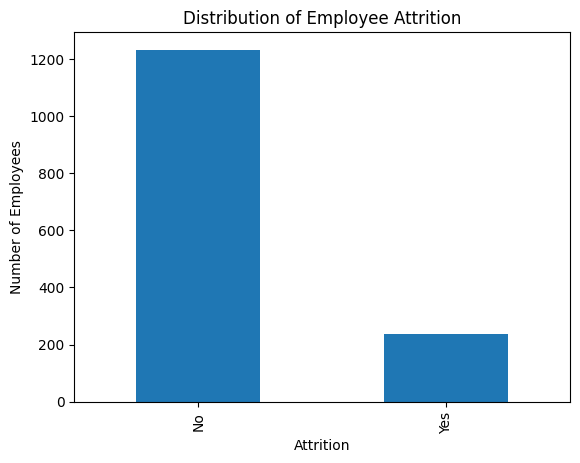

In [37]:

emp['Attrition'].value_counts().plot(kind='bar')
#counts the occurrences of 'Yes' and 'No' in the 'Attrition' column
plt.title('Distribution of Employee Attrition')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.show()



###**🔹Frequency distribution of attrited employees**

Info-: This section performs a frequency distribution analysis on all categorical columns of the attrited employees dataset. For each categorical feature, the code counts how often each category appears, helping to reveal patterns and common characteristics among employees who left the organization.

In [38]:
categorical_cols_attrition = attrition_emp.select_dtypes(include='object').columns

for col in categorical_cols_attrition:
    print(f"\nFrequency distribution for column: {col} in attrited employees")
    print(attrition_emp[col].value_counts())
    print("-" * 30)


Frequency distribution for column: Attrition in attrited employees
Attrition
Yes    237
Name: count, dtype: int64
------------------------------

Frequency distribution for column: Business Travel in attrited employees
Business Travel
Travel_Rarely        156
Travel_Frequently     69
Non-Travel            12
Name: count, dtype: int64
------------------------------

Frequency distribution for column: CF_age band in attrited employees
CF_age band
25 - 34     112
35 - 44      51
Under 25     38
45 - 54      25
Over 55      11
Name: count, dtype: int64
------------------------------

Frequency distribution for column: CF_attrition label in attrited employees
CF_attrition label
Ex-Employees    237
Name: count, dtype: int64
------------------------------

Frequency distribution for column: Department in attrited employees
Department
R&D      133
Sales     92
HR        12
Name: count, dtype: int64
------------------------------

Frequency distribution for column: Education Field in attrited 

Attrition: It shows 237 entries, all 'Yes', confirming that this DataFrame is filtered to only include attrited employees.
Business Travel: A majority of attrited employees (156) travel rarely, followed by 69 who travel frequently, and 12 who do not travel.**The highest attrition occurs in the '25 - 34' age band (112 employees), followed by '35 - 44' (51 employees). This suggests younger to middle-aged employees are more prone to leaving.** The 'R&D' department has the highest number of attrited employees (133), followed by 'Sales' (92), and 'HR' (12). 'Life Sciences' (89) and 'Medical' (63) are the education fields with the most attrited employees.
More male employees (150) attrited than female employees (87). 'Laboratory Technician' (62), 'Sales Executive' (57), and 'Research Scientist' (47) are the job roles with the highest number of attritions.
Marital Status: 'Single' employees (120) have the highest attrition count, followed by 'Married' (84) and 'Divorced' (33).
**Over Time: 127 attrited employees worked overtime, while 110 did not. This indicates a potential link between overtime and attrition.**
**Income_Category: A significant majority of attrited employees fall into the 'Low' income category (163), followed by 'Average' (49).**
**experience_level: 'Mid' (91) and 'Junior' (91) experience levels show the highest number of attrited employees, suggesting that less experienced or mid-career individuals are more likely to leave.**

###***📈Gender Distribution***

    Visualization: Pie Chart (Matplotlib)

    Purpose: To visualize the proportion of male and female employees in the workforce.

    Insight:  The pie chart shows that male employees constitute approximately 60% of the workforce,
    while female employees make up about 40%. This indicates a gender imbalance within the company

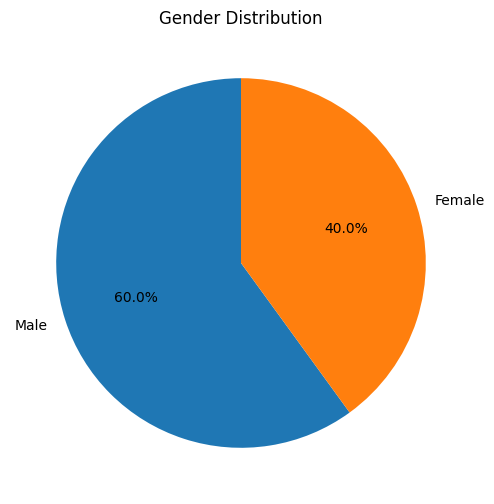

In [39]:
gender_counts = emp['Gender'].value_counts()
#counts how many times each unique gender (Male, Female) appears
plt.figure(figsize=(6,6))
# creates a new plotting figure with a size of 6x6 inches
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
#gender_counts: Provides the numerical values (counts of Male and Female)
#labels=gender_counts.index: Uses the actual gender categories as labels for each slice.
#autopct='%1.1f%%': Formats and displays the percentage value on each slice, showing one decimal place.
#startangle=90: Rotates the starting point of the first slice by 90 degree
plt.title('Gender Distribution')
plt.show()



###***📈Age Distribution***

    Visualization: Histogram (Plotly)
    Purpose: To visualize the frequency distribution of employee ages within the company, identifying the most common age ranges.
    Insight: The histogram reveals that a large portion of employees fall within the age range of 25-40 years old,
    indicating a relatively young workforce. This suggests that younger employees are prevalent in the company.
    The spread of the histogram indicates the age diversity within the company.



In [66]:
fig = px.histogram(emp, x='Age', nbins=15, title='Age Distribution of Employees')
fig.show()

###**🔹Statistical Analysis**

In [41]:
print("Descriptive Statistics for Attrited Employees:")
attrition_emp[['Job Satisfaction','Environment Satisfaction','Performance Rating','Years In Current Role','Work Life Balance','Relationship Satisfaction','Monthly Income','Percent Salary Hike','Years Since Last Promotion',]].describe()
# statistical analysis on a subset of data for the employees who have attrited
#provides a quick summary of the central tendency, dispersion, and shape of the distribution of these key factors for employees who have attrited,

Descriptive Statistics for Attrited Employees:


,Job Satisfaction,Environment Satisfaction,Performance Rating,Years In Current Role,Work Life Balance,Relationship Satisfaction,Monthly Income,Percent Salary Hike,Years Since Last Promotion
count,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000,237.000000
mean,2.468354,2.464135,3.156118,2.902954,2.658228,2.599156,4787.092827,15.097046,1.945148
std,1.118058,1.169791,0.363735,3.174827,0.816453,1.125437,3640.210367,3.770294,3.153077
min,1.000000,1.000000,3.000000,0.000000,1.000000,1.000000,1009.000000,11.000000,0.000000
25%,1.000000,1.000000,3.000000,0.000000,2.000000,2.000000,2373.000000,12.000000,0.000000
50%,3.000000,3.000000,3.000000,2.000000,3.000000,3.000000,3202.000000,14.000000,1.000000
75%,3.000000,4.000000,3.000000,4.000000,3.000000,4.000000,5916.000000,17.000000,2.000000
max,4.000000,4.000000,4.000000,15.000000,4.000000,4.000000,19859.000000,25.000000,15.000000


Job Satisfaction and Environment Satisfaction both have a mean around 2.46-2.47 and a median of 3. This suggests that, on average, attrited employees had moderate to slightly below-average satisfaction in job and environment Satisfaction.

Monthly Income  Attrited employees have a significantly lower average monthly income (mean ~4787) and median income (3202)

Percent Salary Hike shows a mean of about 15.1% and a median of 14%. The values range from 11% to 25%.

Years Since Last Promotion has an average of about 1.95 years and a median of 1 year, with a maximum of 15 years. This suggests that while many received promotions relatively recently, some had gone a considerable time without one.

Years In Current Role: The mean is approximately 2.9 years and the median is 2 years, with a maximum of 15 years. This suggests that a significant number of attrited employees had relatively few years in their current role.

Work Life Balance: The mean is about 2.66 and the median is 3. This indicates that, on average, attrited employees perceived their work-life balance as moderate to slightly below average.

Relationship Satisfaction: The mean is around 2.60 and the median is 3. Similar to job and environment satisfaction, this suggests moderate to slightly below-average relationship satisfaction among attrited employees.


In [42]:
print("Descriptive Statistics for ALL Employees:")
emp[['Job Satisfaction','Environment Satisfaction','Performance Rating','Years In Current Role','Work Life Balance','Relationship Satisfaction','Monthly Income','Percent Salary Hike','Years Since Last Promotion',]].describe()


Descriptive Statistics for ALL Employees:


,Job Satisfaction,Environment Satisfaction,Performance Rating,Years In Current Role,Work Life Balance,Relationship Satisfaction,Monthly Income,Percent Salary Hike,Years Since Last Promotion
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,2.728571,2.721769,3.153741,4.229252,2.761224,2.712245,6502.931293,15.209524,2.187755
std,1.102846,1.093082,0.360824,3.623137,0.706476,1.081209,4707.956783,3.659938,3.222430
min,1.000000,1.000000,3.000000,0.000000,1.000000,1.000000,1009.000000,11.000000,0.000000
25%,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2911.000000,12.000000,0.000000
50%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4919.000000,14.000000,1.000000
75%,4.000000,4.000000,3.000000,7.000000,3.000000,4.000000,8379.000000,18.000000,3.000000
max,4.000000,4.000000,4.000000,18.000000,4.000000,4.000000,19999.000000,25.000000,15.000000


Comparing the descriptive statistics for attrited employees with those for all employees

Job Satisfaction: **Attrited employees tend to have a slightly lower average job satisfaction** (mean ~2.47) compared to all employees (mean ~2.73), though their median satisfaction is the same (3).

Environment Satisfaction: Similarly, attrited employees show a **slightly lower average environment satisfaction** (mean ~2.46) than the overall workforce (mean ~2.72), with the same median of 3.

Monthly Income: This is a notable difference. **Attrited employees have a significantly lower average monthly income** (mean ~4787) and median income (3202) compared to all employees (mean ~6503, median 4919). This suggests that **lower income might be a contributing factor to attrition.**

Percent Salary Hike: The average percent salary hike is very similar for both groups (attrited: ~15.1%, all: ~15.2%), indicating this factor might not be a strong differentiator in attrition.

Years Since Last Promotion: Attrited employees have a slightly lower average number of years since their last promotion (mean ~1.95) compared to all employees (mean ~2.19), but the median is consistent at 1 year for both groups.

Years In Current Role: Attrited employees have a lower average number of years in their current role (mean ~2.90) compared to all employees (mean ~4.23). This suggests that those who leave might not stay long in a particular role.

Work Life Balance: Attrited employees show a slightly lower average work-life balance (mean ~2.66) compared to all employees (mean ~2.76).

Relationship Satisfaction: Similar to other satisfaction metrics, attrited employees tend to have slightly lower average relationship satisfaction (mean ~2.60) than all employees (mean ~2.71).

Performance Rating does not appear to be a significant differentiator between employees who stay and those who leave, as both groups have very similar average and median performance ratings


In summary, ***Monthly Income stands out as the most prominent difference, with attrited employees generally earning less. Lower Job Satisfaction and Environment Satisfaction also appear to be slightly more prevalent among those who leave.***

#***🔹Attrition & Overtime***

In [43]:
Overtime_attrition = emp[
    (emp['Over Time'] == 'Yes') &
    (emp['Attrition'] == 'Yes')]
Overtime_attrition


,Employee Number,Attrition,Business Travel,CF_age band,CF_attrition label,Department,Education Field,emp no,Gender,Job Role,Marital Status,Over Time,Training Times Last Year,Age,CF_current Employee,Daily Rate,Distance From Home,Education,Employee Count,Environment Satisfaction,Hourly Rate,Job Involvement,Job Level,Job Satisfaction,Monthly Income,Monthly Rate,Num Companies Worked,Percent Salary Hike,Performance Rating,Relationship Satisfaction,Standard Hours,Total Working Years,Work Life Balance,Years At Company,Years In Current Role,Years Since Last Promotion,Years With Curr Manager,attrition_n,Income_Category,experience_level
0,1,Yes,Travel_Rarely,35 - 44,Ex-Employees,Sales,Life Sciences,STAFF-1,Female,Sales Executive,Single,Yes,0,41,0,1102,1,Associates Degree,1,2,94,3,2,4,5993,19479,8,11,3,1,80,8,1,6,4,0,5,1,Average,Mid
3,4,Yes,Travel_Rarely,35 - 44,Ex-Employees,R&D,Other,STAFF-4,Male,Laboratory Technician,Single,Yes,3,37,0,1373,2,Associates Degree,1,4,92,2,1,3,2090,2396,6,15,3,2,80,7,3,0,0,0,0,1,Low,Mid
15,19,Yes,Travel_Rarely,25 - 34,Ex-Employees,R&D,Life Sciences,STAFF-19,Male,Laboratory Technician,Single,Yes,4,28,0,103,24,Bachelor's Degree,1,3,50,2,1,3,2028,12947,5,14,3,2,80,6,3,4,2,0,3,1,Low,Mid
27,33,Yes,Travel_Frequently,25 - 34,Ex-Employees,R&D,Life Sciences,STAFF-33,Female,Research Scientist,Single,Yes,5,32,0,1125,16,High School,1,2,72,1,1,1,3919,4681,1,22,4,2,80,10,3,10,2,6,7,1,Low,Mid
35,45,Yes,Travel_Rarely,Under 25,Ex-Employees,R&D,Medical,STAFF-45,Male,Research Scientist,Married,Yes,2,24,0,813,1,Bachelor's Degree,1,2,61,3,1,4,2293,3020,2,16,3,1,80,6,2,2,0,2,0,1,Low,Mid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1377,1939,Yes,Travel_Frequently,25 - 34,Ex-Employees,R&D,Life Sciences,STAFF-1939,Female,Research Scientist,Single,Yes,2,32,0,238,5,Associates Degree,1,1,47,4,1,3,2432,15318,3,14,3,1,80,8,3,4,1,0,3,1,Low,Mid
1397,1967,Yes,Travel_Frequently,25 - 34,Ex-Employees,Sales,Marketing,STAFF-1967,Male,Sales Executive,Married,Yes,4,31,0,754,26,Master's Degree,1,1,63,3,2,4,5617,21075,1,11,3,3,80,10,3,10,7,0,8,1,Average,Mid
1398,1968,Yes,Travel_Rarely,45 - 54,Ex-Employees,Sales,Life Sciences,STAFF-1968,Male,Sales Executive,Single,Yes,2,53,0,1168,24,Master's Degree,1,1,66,3,3,1,10448,5843,6,13,3,2,80,15,2,2,2,2,2,1,Good,Senior
1444,2027,Yes,Travel_Rarely,25 - 34,Ex-Employees,R&D,Medical,STAFF-2027,Male,Research Scientist,Married,Yes,3,29,0,1092,1,Master's Degree,1,1,36,3,1,4,4787,26124,9,14,3,2,80,4,4,2,2,2,2,1,Low,Junior


In [44]:
len(Overtime_attrition)

127

Info-: Employees who both worked overtime ('Over Time' is 'Yes') and subsequently left the company ('Attrition' is 'Yes').
Out of 237 attrited employees, 127 had worked overtime.
This filtered dataset highlights a specific subgroup of ex-employees, which can be useful for investigating the relationship between overtime work and attrition.



In [45]:
attrition_overtime = emp.groupby('Over Time')['Attrition'].value_counts(normalize=True).unstack() * 100
attrition_overtime
# calculates the attrition percentage for employees based on their 'Over Time' status.


Attrition,No,Yes
Over Time,,
No,89.563567,10.436433
Yes,69.471154,30.528846


Info-: The output from attrition_overtime clearly shows that employees who work overtime ('Yes') have a significantly higher attrition rate (30.53%) compared to those who do not work overtime ('No'), whose attrition rate is 10.44%.

###📈***Distribution of Employee Attrition & Overtime***

    Visualization: Bar chart(Matplotlib)

    Purpose:To visualize and compare the attrition rates between employees who work overtime and those who do not.
  
    Insight: Employees who work overtime are nearly three times more likely to leave the company (30.53% vs 10.44%).
    This suggests a strong correlation between working overtime and employee attrition.

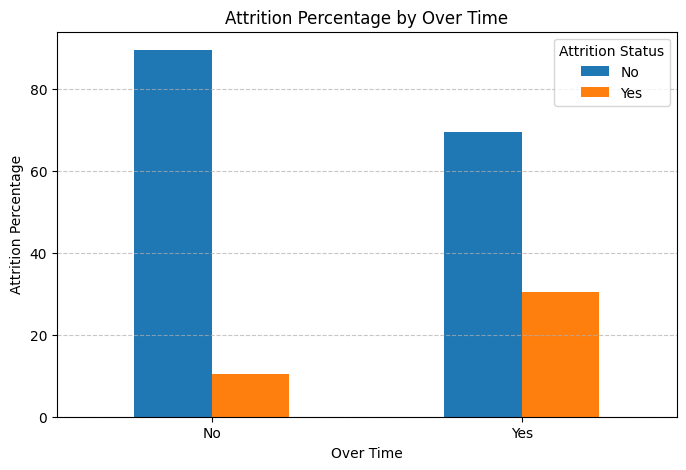

In [46]:
attrition_overtime.plot(kind='bar', figsize=(8, 5))
plt.title('Attrition Percentage by Over Time')
plt.xlabel('Over Time')
plt.ylabel('Attrition Percentage')
plt.legend(title='Attrition Status')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#***🔹Attrition vs Job Satisfaction***

In [47]:
job_sat_attrition = emp.groupby('Job Satisfaction')['Attrition'].value_counts(normalize=True).unstack() * 100
job_sat_attrition
#calculates the attrition percentage for employees based on their 'Job Satisfaction' level.


Attrition,No,Yes
Job Satisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


Info-: Employees with very low job satisfaction are more than twice as likely to leave the company compared to those with very high job satisfaction.

###📈***Distribution of Attrition by Job satisfaction***

    Visualization: Bar Chart (Matplotlib)

    Purpose:To visualize how job satisfaction levels influence employee attrition rates.

    Insight:Employees with very low job satisfaction are more than twice as likely to leave the company compared to
    those with very high job satisfaction. This suggests that job satisfaction is a critical factor influencing employee retention.

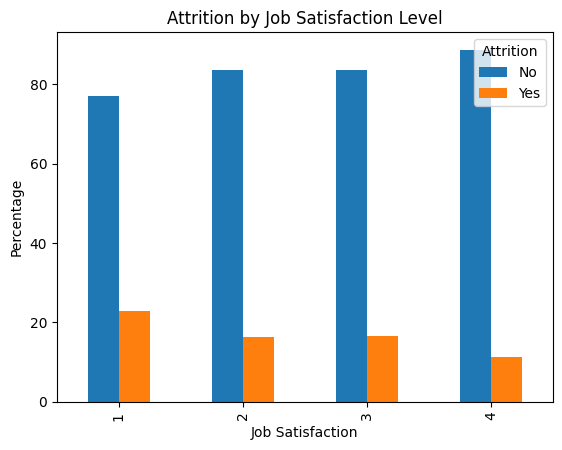

In [48]:
job_sat_attrition.plot(kind='bar')
plt.title('Attrition by Job Satisfaction Level')
plt.xlabel('Job Satisfaction')
plt.ylabel('Percentage')
plt.show()


**Job Satisfaction Level 1 (Low): Approximately 22.84% of employees with the lowest job satisfaction attrited.**

**Job Satisfaction Level 2: Approximately 16.43% of employees with this satisfaction level attrited.**

**Job Satisfaction Level 3: Approximately 16.52% of employees with this satisfaction level attrited.**

**Job Satisfaction Level 4 (High): Only about 11.33% of employees with the highest job satisfaction attrited.**

**This indicates a strong inverse relationship: as job satisfaction increases, the attrition rate significantly decreases. Employees with very low job satisfaction are more than twice as likely to leave the company compared to those with very high job satisfaction. This suggests that job satisfaction is a critical factor influencing employee retention.**

##**iv. Multivariate analysis**
*  Distribution of Years at Company vs Attrition
* Department, Over Time and Attrition
* Attrition Based on Age Group
* Attrition vs Monthly Income
* Correlation Matrix

###📈***Distribution of Years at Company vs Attrition***
    
    Visualization: Scatter Plot(Seaborn)

    Purpose:To visualize the relationship between an employee's years at the company, their monthly income,
    and their attrition status, identifying patterns where these factors might contribute to employees leaving or staying.

    Insight:Employees with both Less experience at the company and lower income are particularly prone to attrition.
    High-income, more experience employees are less likely to leave.


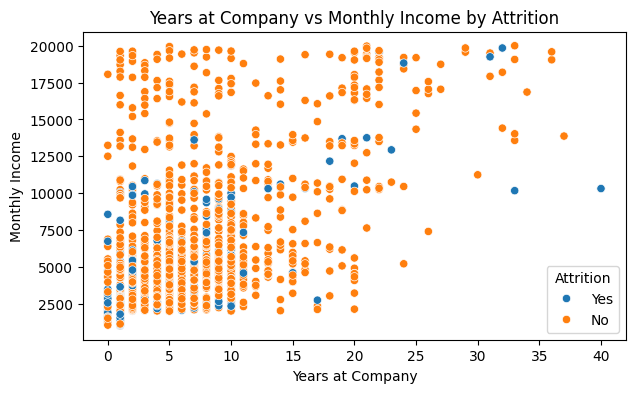

In [49]:
plt.figure(figsize=(7,4))
sns.scatterplot(x='Years At Company', y='Monthly Income', hue='Attrition', data=emp)
plt.title('Years at Company vs Monthly Income by Attrition')
plt.xlabel('Years at Company')
plt.ylabel('Monthly Income')
plt.show()
#generates a scatter plot to visualize the relationship between 'Years At Company' and 'Monthly Income',
#with different colors indicating whether an employee attrited or not.


**Income and Attrition: Attrited employees (represented by blue color) might be more concentrated in the lower to mid-range of monthly incomes, especially when compared to employees who remain with the company.**

**Years at company and Attrition: There might be a higher density of attrited employees among those with fewer years at the company. However, some attrition might still occur at higher tenure levels, possibly indicating dissatisfaction despite long service.**

#***🔹Department, Over Time and Attrition***

In [50]:
pivot_dept_ot = pd.pivot_table(emp,
    values='Employee Count',
    index='Department',
    columns=['Over Time', 'Attrition'],
    aggfunc='count',
    fill_value=0)
pivot_dept_ot
#generates a pivot table that summarizes the count of employees based on their Department,
#whether they work Over Time, and their Attrition status.

Over Time    No      Yes    
Attrition    No Yes   No Yes
Department                  
HR           39   7   12   5
R&D         631  59  197  74
Sales       274  44   80  48

Info-:Overtime and Attrition Correlation: Across all departments, employees who work overtime consistently show a higher number of attritions compared to those who do not work overtime.

In the Sales department, 48 employees who work overtime attrited, compared to 44 who did not work overtime.
In R&D, 74 overtime employees attrited versus 59 non-overtime employees.
Departmental Differences:

R&D Department: This department has the highest number of employees overall, and also the highest number of employees who did not attrite (631 without overtime, 197 with overtime). However, it also has the highest absolute number of attrited employees (59 + 74 = 133).
Sales Department: Shows a particularly high number of attritions among employees working overtime (48), relative to its size compared to R&D. The attrition rate for sales employees working overtime seems notably high.
HR Department: Has the lowest overall employee count but still exhibits attrition, especially among those working overtime.
This breakdown suggests that overtime work is a significant factor contributing to attrition across the company, and certain departments like Sales might be more heavily impacted by this dynamic.

In [51]:
#Attrition RATE by Department
attrition_rate = (emp.groupby('Department')['attrition_n'].mean())
attrition_rate


,attrition_n
Department,
HR,0.190476
R&D,0.138398
Sales,0.206278


Info-: Sales and HR departments may face greater challenges in retaining employees compared to R&D.



**Job role & Attrition**

In [52]:
pivot_jb_role = pd.pivot_table(emp,
    values='Employee Count',
    index='Job Role',
    columns='Attrition',
    aggfunc='count',
    fill_value=0)
pivot_jb_role
#generates a pivot table that summarizes the count of employees based on their 'Job Role' and 'Attrition' status.

Attrition,No,Yes
Job Role,,
Healthcare Representative,122,9
Human Resources,40,12
Laboratory Technician,197,62
Manager,97,5
Manufacturing Director,135,10
Research Director,78,2
Research Scientist,245,47
Sales Executive,269,57
Sales Representative,50,33


**Job roles with more direct sales or technical support functions (Sales Executive, Laboratory Technician, Sales Representative) might face higher attrition challenges, while managerial and research director roles have better retention.**

###📈**Distribution of Attrition by Department & Job Role**

    Visualization: Subplots (seaborn)

    Purpose: To identify which specific job roles experience higher or
    lower rates of attrition within the company.

    Insight:  job roles with more direct sales or technical support functions
    (such as 'Sales Executive', 'Laboratory Technician', and 'Sales Representative') tend to face higher attrition challenges.
    Conversely, managerial roles and 'Research Director' positions show better retention rates.

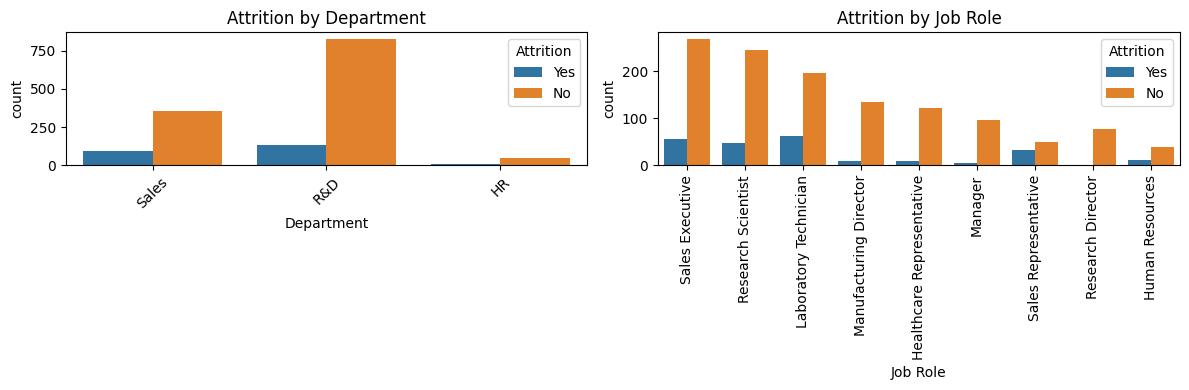

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.countplot(x='Department', hue='Attrition', data=emp, ax=axes[0])
axes[0].set_title('Attrition by Department')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(x='Job Role', hue='Attrition', data=emp, ax=axes[1])
axes[1].set_title('Attrition by Job Role')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


#***🔹Attrition Based on Age Group***

In [54]:
#Employees older than 40 in attrition
senior_attrition = emp[
    (emp['Age'] > 40) &
    (emp['Attrition'] == 'Yes')]
senior_attrition.head(5)



,Employee Number,Attrition,Business Travel,CF_age band,CF_attrition label,Department,Education Field,emp no,Gender,Job Role,Marital Status,Over Time,Training Times Last Year,Age,CF_current Employee,Daily Rate,Distance From Home,Education,Employee Count,Environment Satisfaction,Hourly Rate,Job Involvement,Job Level,Job Satisfaction,Monthly Income,Monthly Rate,Num Companies Worked,Percent Salary Hike,Performance Rating,Relationship Satisfaction,Standard Hours,Total Working Years,Work Life Balance,Years At Company,Years In Current Role,Years Since Last Promotion,Years With Curr Manager,attrition_n,Income_Category,experience_level
0,1,Yes,Travel_Rarely,35 - 44,Ex-Employees,Sales,Life Sciences,STAFF-1,Female,Sales Executive,Single,Yes,0,41,0,1102,1,Associates Degree,1,2,94,3,2,4,5993,19479,8,11,3,1,80,8,1,6,4,0,5,1,Average,Mid
37,47,Yes,Travel_Rarely,45 - 54,Ex-Employees,Sales,Marketing,STAFF-47,Male,Sales Representative,Married,Yes,2,50,0,869,3,Associates Degree,1,1,86,2,1,3,2683,3810,1,14,3,3,80,3,3,3,2,0,2,1,Low,Junior
46,58,Yes,Travel_Rarely,35 - 44,Ex-Employees,R&D,Technical Degree,STAFF-58,Female,Research Director,Married,No,0,41,0,1360,12,Bachelor's Degree,1,2,49,3,5,3,19545,16280,1,12,3,4,80,23,3,22,15,15,8,1,High,Expert
51,64,Yes,Travel_Rarely,45 - 54,Ex-Employees,R&D,Life Sciences,STAFF-64,Male,Laboratory Technician,Single,Yes,2,48,0,626,1,Associates Degree,1,1,98,2,3,3,5381,19294,9,13,3,4,80,23,3,1,0,0,0,1,Average,Expert
90,118,Yes,Travel_Rarely,45 - 54,Ex-Employees,Sales,Medical,STAFF-118,Male,Sales Executive,Single,No,3,46,0,669,9,Associates Degree,1,3,64,2,3,4,9619,13596,1,16,3,4,80,9,3,9,8,4,7,1,Average,Mid


This DataFrame, senior_attrition, contains only those employees who are older than 40 years of age AND whose 'Attrition' status is 'Yes'.
This specifically highlights older employees who have left the company, which can be useful for analyzing attrition patterns within this demographic.


In [55]:
len(senior_attrition)

52

52 employees above 40 left the company, Larger number of employees from the 'Below 40' age group (185 employees) attrited. This suggests that while attrition occurs across all age groups, the younger demographic appears to be more prone to leaving the company.

In [56]:
emp['Age Group'] = emp['Age'].apply(
    lambda x: 'Above 40' if x > 40 else 'Below 40')
emp[['Age', 'Age Group']]
#creates a new column named Age Group in the emp DataFrame. It categorizes each employee as 'Above 40' if their Age is greater than 40, and 'Below 40' otherwise.

,Age,Age Group
0,41,Above 40
1,49,Above 40
3,37,Below 40
4,33,Below 40
5,27,Below 40
...,...,...
1467,36,Below 40
1468,39,Below 40
1469,27,Below 40
1470,49,Above 40


Larger number of employees from the 'Below 40' age group  attrited. This suggests that while attrition occurs across all age groups, the younger demographic appears to be more prone to leaving the company.

In [57]:
pivot_age_dept = pd.pivot_table(
    emp,values='Employee Count',
    index='Department',
    columns=['Age Group', 'Attrition'],
    aggfunc='count',
    fill_value=0)
pivot_age_dept
#generates a pivot table that summarizes the count of employees based on their 'Department', 'Age Group', and 'Attrition' status.


Age Group  Above 40     Below 40     
Attrition        No Yes       No  Yes
Department                           
HR               23   1       28   11
R&D             281  27      547  106
Sales           109  24      245   68

The 'Below 40' age group generally shows a higher number of attritions across all departments compared to the 'Above 40' group.

###📈**Distribution of Department wise Attrition by Age group**

Visualizations:Stacked bar chart (Matplotlib)

Purpose: To analyze and compare attrition patterns across different departments, specifically broken down by age group (Above 40 vs. Below 40).

Insight: The 'Below 40' age group generally shows a higher number of attritions across all departments compared to the 'Above 40' group.

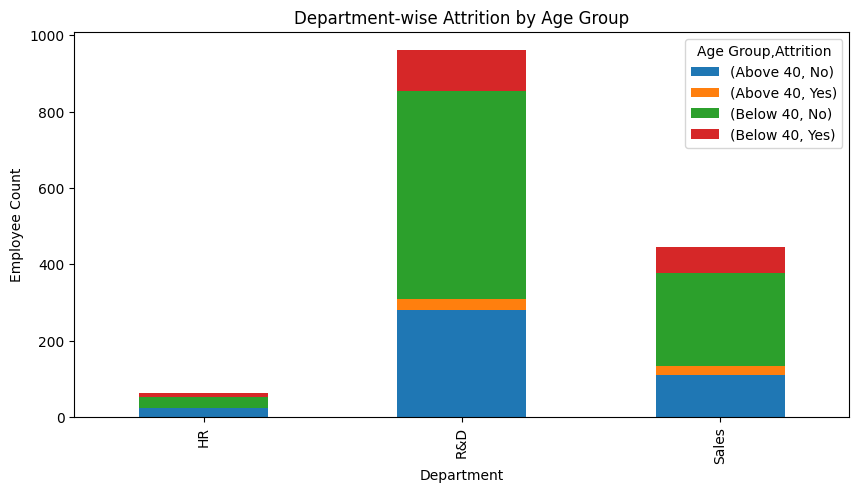

In [58]:
pivot_age_dept.plot(kind='bar', stacked=True, figsize=(10,5))
plt.title('Department-wise Attrition by Age Group')
plt.xlabel('Department')
plt.ylabel('Employee Count')
plt.show()
#Generates a stacked bar chart to visualize attrition patterns across different departments, broken down by age group.


Info-: Overall Attrition: The 'Below 40' age group generally shows a higher number of attritions across all departments compared to the 'Above 40' group.

In R&D, 106 employees 'Below 40' attrited, versus 27 employees 'Above 40'.
In Sales, 68 employees 'Below 40' attrited, versus 24 employees 'Above 40'.
Departmental Trends:

R&D has the highest total number of employees and, consequently, the highest number of both current and attrited employees in both age groups. The bulk of attrition in R&D comes from the 'Below 40' group.

Sales also experiences significant attrition, again with the 'Below 40' group showing more leavers.

HR has the smallest numbers overall, but still shows that attrition is more prevalent in the 'Below 40' age group.

Age Group Vulnerability: Employees in the 'Below 40' age group appear to be more susceptible to attrition across all departments, which could point to factors like early career dissatisfaction, lack of growth opportunities, or competitive external job markets for younger talent.

##***🔹Attrition vs Monthly Income***

In [59]:
emp.groupby('Attrition')['Monthly Income'].mean()


,Monthly Income
Attrition,
No,6832.739659
Yes,4787.092827


Info-: Employees who attrited had a substantially lower average monthly income compared to those who remained with the company. This reinforces the idea that lower compensation is a critical factor contributing to employee attrition.

In [60]:
#Average Monthly Income by Job Role
emp.groupby('Job Role')['Monthly Income'].mean().reset_index()




,Job Role,Monthly Income
0,Healthcare Representative,7528.763359
1,Human Resources,4235.750000
2,Laboratory Technician,3237.169884
3,Manager,17181.676471
4,Manufacturing Director,7295.137931
5,Research Director,16033.550000
6,Research Scientist,3239.972603
7,Sales Executive,6924.279141
8,Sales Representative,2626.000000


Info-: Healthcare Representative' has an average monthly income of 7528.76, while 'Manager' has a significantly higher average of 17181.67.
This helps in understanding the income distribution across different job roles within the company.

###📈**Distribution of Monthly Income by Attrition**

    Visualization: Boxplot (Seaborn)

    Purpose: To compare the distribution of 'Monthly Income' between employees who have attrited and
    those who have not, helping to identify if income levels play a role in attrition.

    Insight: Lower monthly income is a contributing factor to employee attrition.

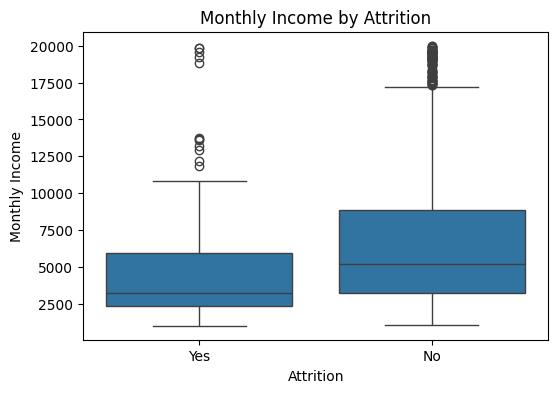

In [61]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Attrition', y='Monthly Income', data=emp)
plt.title('Monthly Income by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
plt.show()
#generates a box plot to compare the distribution of 'Monthly Income' between employees who have attrited ('Yes') and those who have not ('No')


Info-: Attrited employees (Attrition = 'Yes') generally have a lower median monthly income compared to current employees (Attrition = 'No'). The box for attrited employees will likely be positioned lower on the y-axis.

The spread of monthly income (interquartile range) for attrited employees might also be narrower or lower, suggesting that a significant portion of those who leave are concentrated in lower income brackets.

This visual comparison reinforces the earlier statistical analysis, indicating that lower monthly income is a contributing factor to employee attrition.

##**🔹Correlation Matrix**

In [62]:
numeric_cols = ['Age', 'Monthly Income', 'Job Satisfaction',
    'Work Life Balance', 'Years At Company',
    'Total Working Years']
corr_matrix = emp[numeric_cols].corr()
corr_matrix
#calculates the correlation matrix for Age Monthly Income Job Satisfaction Work Life Balance Years At Company Total Working Years columns of emp DataFrame.


,Age,Monthly Income,Job Satisfaction,Work Life Balance,Years At Company,Total Working Years
Age,1.000000,0.497855,-0.004892,-0.021490,0.311309,0.680381
Monthly Income,0.497855,1.000000,-0.007157,0.030683,0.514285,0.772893
Job Satisfaction,-0.004892,-0.007157,1.000000,-0.019459,-0.003803,-0.020185
Work Life Balance,-0.021490,0.030683,-0.019459,1.000000,0.012089,0.001008
Years At Company,0.311309,0.514285,-0.003803,0.012089,1.000000,0.628133
Total Working Years,0.680381,0.772893,-0.020185,0.001008,0.628133,1.000000


Note-:
Values range from -1 to 1:

1: Perfect positive correlation (as one variable increases, the other increases proportionally).

-1: Perfect negative correlation (as one variable increases, the other decreases proportionally).

0: No linear correlation.

###📈**Distribution of Heatmap**

    Visualization: Heatmap (seaborn)
     
    Purpose: To quantitatively understand the linear relationships between pairs of numerical variables
    (Age, Monthly Income, Job Satisfaction, Work Life Balance, Years At Company, Total Working Years) in the dataset.

    Insight: Age, Monthly Income, Total Working Years, and Years At Company are interconnected,
    Job Satisfaction and Work Life Balance appear to be independent factors within this dataset.

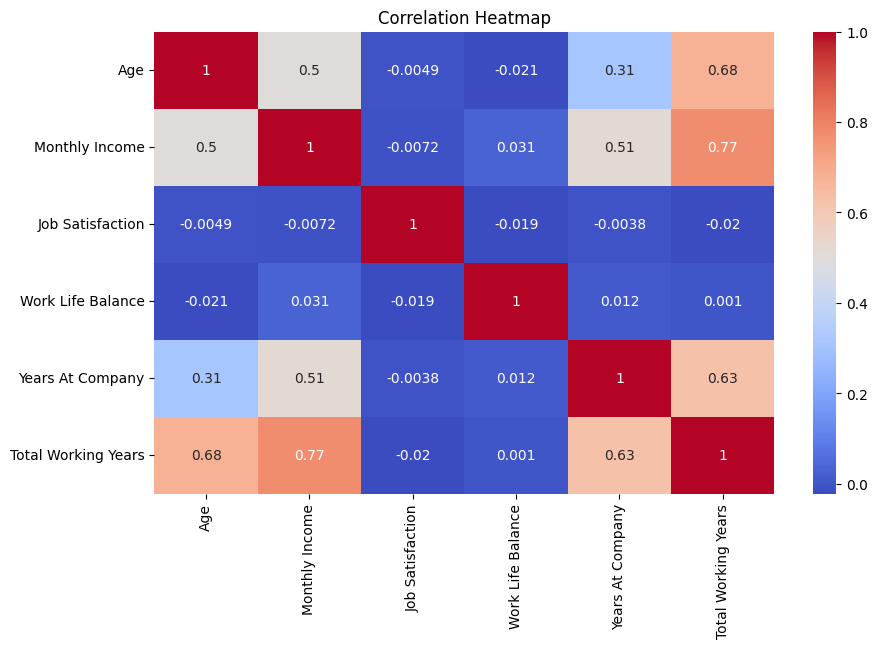

In [63]:
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Info-: Strong Positive Correlations: Monthly Income increases significantly with Total Working Years and Age. Years At Company is also positively linked to Monthly Income and Total Working Years.

Weak/No Correlations: Job Satisfaction and Work Life Balance show very little linear relationship with any of the other variables, suggesting they operate independently of factors like age, income, and tenure.
while Age, Monthly Income, Total Working Years, and Years At Company are interconnected, Job Satisfaction and Work Life Balance appear to be independent factors within this dataset.

#**INSIGHT GENERATION AND REPORT**

##Objective of the Analysis

The objective of this project is to analyze employee attrition data to identify key demographic, professional, performance, and workplace factors associated with employee turnover. Through systematic data preprocessing, exploratory data analysis (EDA), and comprehensive visual analytics, the study aims to uncover meaningful patterns that support better understanding of attrition trends and help organizations design effective employee retention strategies.

## Summary of Data Preperation

- The dataset, `Workforce_Data.xlsx`, contains `1470` rows and `40` columns after initial processing, providing comprehensive employee information.
- The `emp` DataFrame includes a mix of numerical (`int64`, `float64`) and categorical (`object`) data types, covering various employee attributes such as `Employee Number`, `Attrition`, `Age`, `Department`, `Monthly Income`, and `Job Role`.
- 2 duplicate rows were identified and subsequently dropped, ensuring data uniqueness.
- 4 missing values were found in the Gender column, which were filled using the mode
-  Unnecessary columns such as Stock Option Level and Over18 were dropped as they were deemed less useful for the analysis.
- The Attrition column was converted into a numerical format
- 2 new Derived Columns were created

## Summary of Key Insights on Employee Attrition

Based on the Exploratory Data Analysis, the following are the most significant insights regarding employee attrition:

1.  **Overtime Work:** Employees who work overtime are nearly three times more likely to leave the company (30.53% attrition rate) compared to those who do not work overtime (10.44% attrition rate). This suggests a strong negative impact of overtime on employee retention.

2.  **Job Satisfaction:** A strong inverse relationship exists between job satisfaction and attrition. Employees with the lowest job satisfaction (Level 1) have an attrition rate of approximately 22.84%, which is more than double the attrition rate of employees with the highest job satisfaction (Level 4, ~11.33%). This highlights job satisfaction as a critical factor for employee retention.

3.  **Monthly Income:** Attrited employees have a significantly lower average monthly income (4787) and median income (3202) compared to all employees (6503 and 4919, respectively). The box plot for Monthly Income clearly shows that employees with lower monthly incomes are more prone to attrition, suggesting that financial compensation is a key driver for leaving.

4.  **Age Group:** The 'Below 40' age group generally shows a higher number of attritions across all departments compared to the 'Above 40' group. Specifically, in R&D, 106 employees 'Below 40' attrited versus 27 'Above 40', and in Sales, 68 'Below 40' attrited versus 24 'Above 40'. This indicates that younger employees are more susceptible to attrition.

5.  **Years in Current Role:** Attrited employees have a lower average number of years in their current role (mean ~2.90) compared to all employees (mean ~4.23). This suggests that employees who leave might not stay long in a particular role, possibly due to lack of career progression or quick dissatisfaction.

6.  **Job Role and Department:** Certain job roles, particularly 'Laboratory Technician' (62 attritions) and 'Sales Executive' (57 attritions), and 'Sales Representative' (33 attritions), show higher attrition counts. In terms of departments, R&D and Sales have the highest absolute numbers of attrited employees. These roles and departments might experience specific stressors or lack adequate support leading to higher turnover.

7.  **Relationship Satisfaction & Work Life Balance**: Attrited employees show slightly lower average relationship satisfaction (mean ~2.60 vs. ~2.71 for all employees) and work-life balance (mean ~2.66 vs. ~2.76 for all employees). While not as pronounced as income or job satisfaction, these factors contribute to overall employee well-being and can influence the decision to leave.

#Conclusion
The employee attrition analysis reveals that turnover is strongly influenced by a combination of workload, satisfaction, compensation, age, role stability, and workplace environment. Employees who frequently work overtime, receive lower salaries, and report low job satisfaction are significantly more likely to leave the organization. Younger employees, particularly those below 40, and those who have spent fewer years in their current role also show higher attrition tendencies, indicating possible concerns related to career growth and early job dissatisfaction.

 # ***Recommendations to Reduce Employee Attrition***
 Actionable recommendations include:

  *   Implementing stricter policies on overtime work and promoting work-life balance initiatives.

  *   Improving job satisfaction through regular surveys, career development programs, and skill enhancement opportunities.

  *   Conducting a comprehensive review of compensation structures to ensure competitive salaries.

  *   Developing mentorship programs and clear career progression paths for younger employees, especially those 'Below 40'.

  *   Enhancing role longevity and career growth through internal mobility programs and regular performance reviews.

  *   Conducting targeted analyses within high-attrition departments (Sales, R&D) and job roles (Laboratory Technician, Sales Executive, Sales Representative) to understand specific drivers.

  *   Fostering a positive work environment, promoting flexible work arrangements, and providing mental health resources to improve relationship satisfaction and work-life balance.